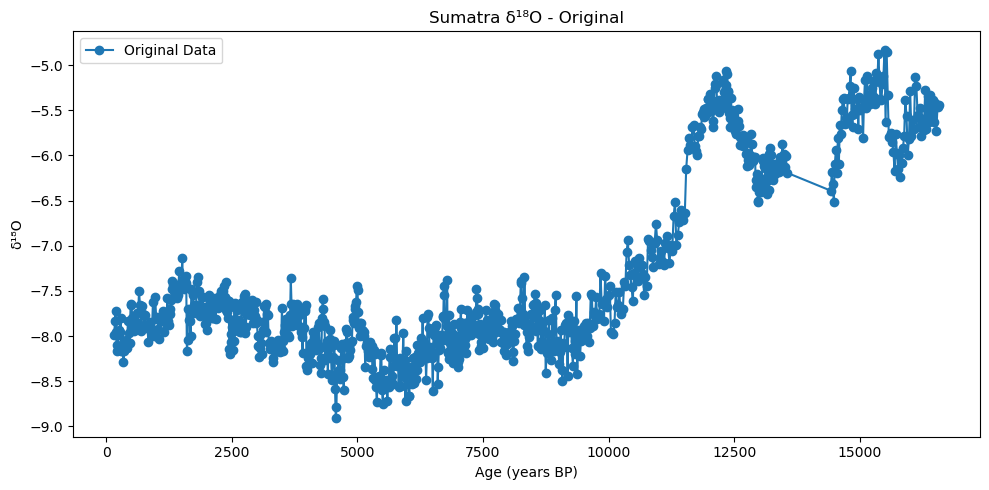

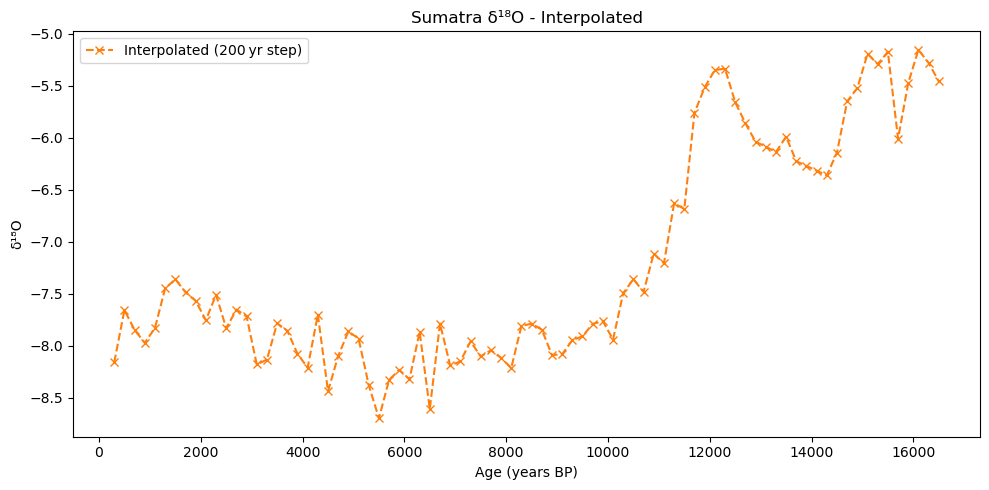

,age,d18O_diff
0,7700,0.088600
1,7900,0.071800
2,8100,-0.044133
3,8300,-0.133726
4,8500,0.050300
...,...,...
76,22900,0.035200
77,23100,-0.025409
78,23300,-0.019667
79,23500,0.017444


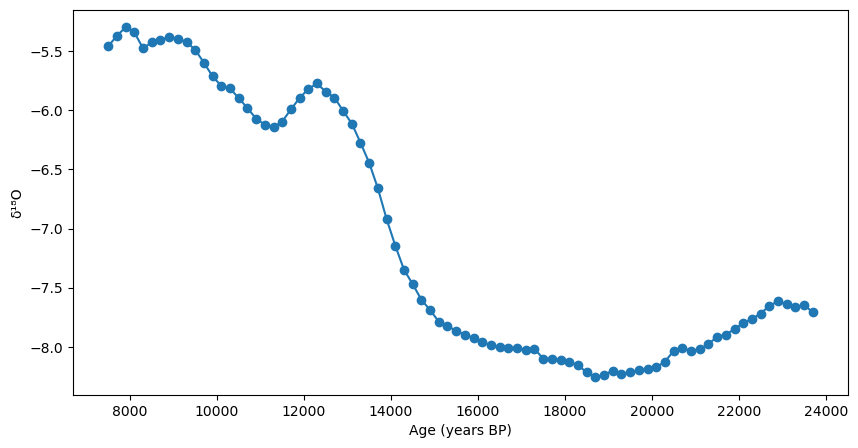

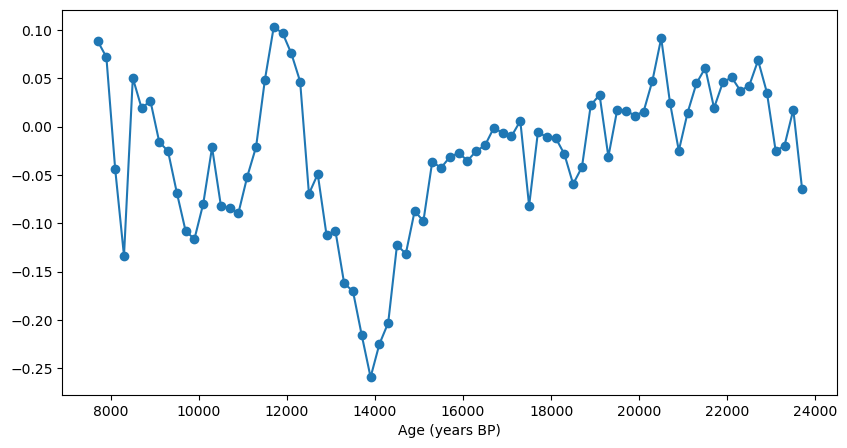

In [55]:
import pandas as pd

# 1) Read in the full file (if you haven’t already)
file_path = r"D:\VScode\Inso_LGMR\other_data\Sumatra_d18O.txt"
df_d18O = pd.read_csv(
    file_path,
    delim_whitespace=True,  # or sep='\t' if tab‑delimited
    comment='#',
    header=0
)

# 2) Extract & rename
df_d18O = (
    df_d18O
      .loc[:, ['age_calkaBP', 'd18O-IVcorr']]
      .rename(columns={
          'age_calkaBP': 'age',
          'd18O-IVcorr': 'd18O'
      })
)

# age= age * 1000 
df_d18O['age'] = df_d18O['age'] * 1000

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 4) Plot original data
plt.figure(figsize=(10, 5))
plt.plot(df_d18O['age'], df_d18O['d18O'], 'o-', label='Original Data')
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Sumatra δ¹⁸O - Original')
plt.legend()
plt.tight_layout()
plt.show()

# # 5) Interpolate for age = 200 to 16500 in steps of 200
new_age = np.arange(300, 16501, 200)
new_d18O = np.interp(new_age, df_d18O['age'], df_d18O['d18O'])

# 6) Plot interpolated data
plt.figure(figsize=(10, 5))
plt.plot(new_age, new_d18O, 'x--', color='C1', label='Interpolated (200 yr step)')
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Sumatra δ¹⁸O - Interpolated')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: assemble into a DataFrame
df_d18O_interp = pd.DataFrame({'age': new_age, 'd18O': new_d18O})
# df_d18O_interp.head()


df_d18O_interp = df_d18O_interp.iloc[::-1]



# shift the age column
df_d18O_interp['age'] = df_d18O_interp['age'] * -1 + 24000

df_d18O_interp['d18O'] = df_d18O_interp['d18O'].rolling(window=10, min_periods=1).mean()

# plot data and the smoothed data
plt.figure(figsize=(10, 5))
plt.plot(df_d18O_interp['age'], df_d18O_interp['d18O'], 'o-', label='Smoothed Data')
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')


# calculate the diff
df_d18O_interp['d18O_diff'] = df_d18O_interp['d18O'].diff()
# drop the column co2
df_d18O_interp = df_d18O_interp.drop(columns=['d18O'])

# drop the last row of df_co2
df_d18O_interp = df_d18O_interp.drop(df_d18O_interp.index[0])
# reindex the dataframe
df_d18O_interp = df_d18O_interp.reset_index(drop=True)


# plot diff
plt.figure(figsize=(10, 5))
plt.plot(df_d18O_interp['age'], df_d18O_interp['d18O_diff'], 'o-', label='Smoothed Data')
plt.xlabel('Age (years BP)')


df_d18O_interp
# df_d18O


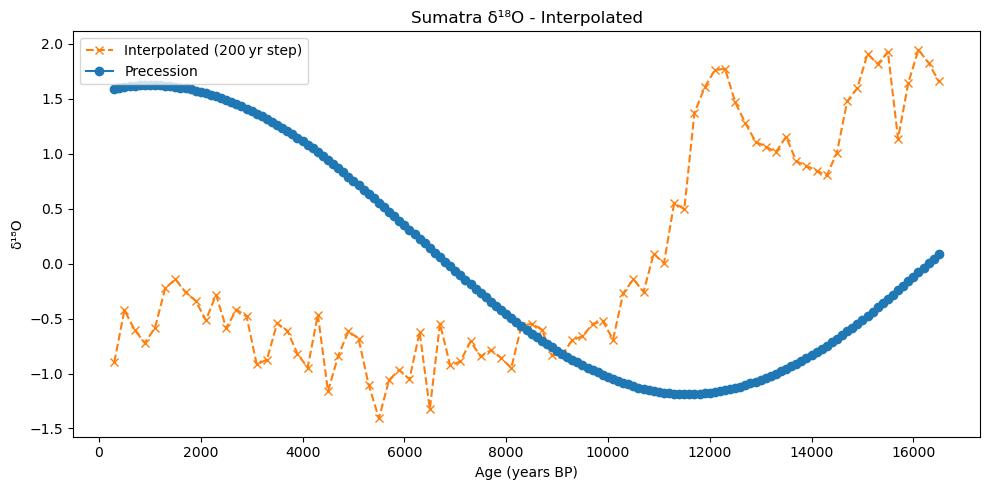

,age,pre
0,7700.0,-0.004078
1,7900.0,-0.005155
2,8100.0,-0.006222
3,8300.0,-0.007275
4,8500.0,-0.008309
...,...,...
76,22900.0,0.017109
77,23100.0,0.017104
78,23300.0,0.017029
79,23500.0,0.016891


In [49]:
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt

# Read the file into a DataFrame
df_pre = pd.read_csv(
    r"D:\VScode\Inso_LGMR\inso_data\pre.txt", 
    sep='\s+',       # '\s+' means "split on any whitespace"
    header=None,     # or specify a row number if there's a header
    engine='python'
)


df_pre.iloc[:, 0] = df_pre.iloc[:, 0].abs() * 1000


# Rename the columns
df_pre.columns = ['age', 'pre']


# crop the data for age>=100 <=23900
df_pre = df_pre[(df_pre['age'] >= 300) & (df_pre['age'] <= 16500)]

plt.figure(figsize=(10, 5))
plt.plot(new_age, zscore(new_d18O), 'x--', color='C1', label='Interpolated (200 yr step)')
plt.plot(df_pre['age'], zscore(df_pre['pre']), 'o-', label='Precession')
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Sumatra δ¹⁸O - Interpolated')
plt.legend()
plt.tight_layout()
plt.show()

# remove rows that can be divided by 200
df_pre = df_pre[df_pre['age'] % 200 != 0]


# the age column * -1 +24000
df_pre['age'] = df_pre['age'] * -1 + 24000


# drop the last row of df_pre and df_obl
df_pre = df_pre.drop(df_pre.index[0])
# reindex the dataframe
df_pre = df_pre.reset_index(drop=True)

df_pre


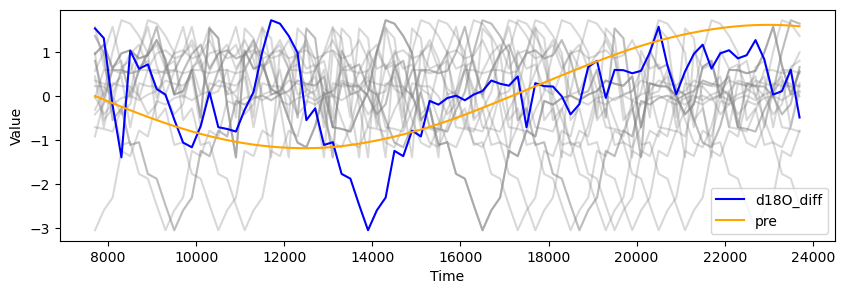

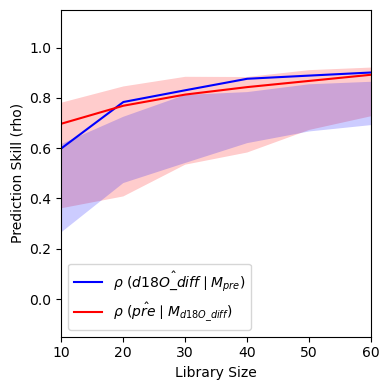

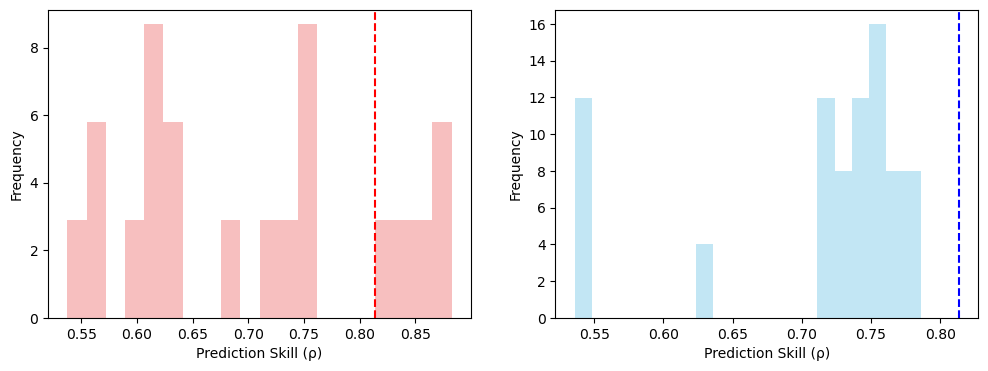

(False, True)


In [56]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)



df_merged = pd.DataFrame({
    'age':       df_d18O_interp['age'].values,
    'd18O_diff': df_d18O_interp['d18O_diff'].values,
    'pre':       df_pre['pre'].values
})


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)